In [1]:
### IMPORT

# lettuce
import lettuce as lt
# unit conversion...

# os and data management
import datetime
import os, shutil
# from pyevtk.hl import imageToVTK
from glob import glob

# calculation
import numpy as np
# torch
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# plotting
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.rcParams['agg.path.chunksize'] = 1000

matplotlib.style.use('../figure_style.mplstyle')

In [2]:
### DATA I/O settings
data_base_path = "/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data"


In [3]:
# PARAMETERS

mas = [0.05] #[0.05, 0.1, 0.2]
res = [10000] #[10000, 20000, 35000]
gbcs = ['fwbb', 'hwbb'] #['fwbb', 'hwbb', 'ibb']


In [4]:
### CREATE PATH-DICT for all parameter-combinations and respective data on cluster/work/...

paths_dict_ref = dict()
paths_dict_reduced = dict()

for ma in mas:
    for re in res:
        for gbc in gbcs:
            paths_dict_reduced[ma,re,gbc] = []
            paths_dict_ref[ma,re,gbc] = []
            dir_names_reduced = glob(data_base_path + "/*plate_10x10x1PU_HL100_kbc_T20000_" + "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
            dir_names_ref = glob(data_base_path + "/*REF_plate_full_HL100_kbc_T20000_" + "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
            
            if len(dir_names_reduced)>1:
                print("(!) Warning: more than 1 simulation for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                print(dir_names_reduced)
            elif len(dir_names_reduced) == 1:
                # this is what we want: one unique simulation found
                paths_dict_reduced[ma,re,gbc].append(*dir_names_reduced)
            else:
                print("(!) Warning: no path found for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                
            if len(dir_names_ref)>1:
                print("(!) Warning: more than 1 simulation for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                print(dir_names_ref)
            elif len(dir_names_ref) == 1:
                # this is what we want: one unique simulation found
                paths_dict_ref[ma,re,gbc].append(*dir_names_ref)
            else:
                print("(!) Warning: no path found for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)

In [5]:
### data_series identifiers

# x_positions:
x_positions = [1,2,3]
y_positions = [0,1,2,3]

data_file_prefix = "p_xyz"  # later change to "up_xyz", for sims. after 26.11.24 (!)

In [6]:
print(paths_dict_ref)

{(0.05, 10000, 'fwbb'): ['/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb'], (0.05, 10000, 'hwbb'): ['/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Ghwbb']}


In [7]:
# load timeseries
# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5
pu_timeseries_dict_reduced = dict()
pu_timeseries_dict_ref = dict()

for ma in mas:
    for re in res:
        for gbc in gbcs:
            for x_position in x_positions:
                for y_position in y_positions:
                  #  print("loading:", "Ma"+str(ma),"Re"+str(re),"G"+gbc, "/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    
                    # search for string REF:
                    print("searching: ", paths_dict_ref[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    matches = glob(paths_dict_ref[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    if len(matches)>1:
                        print("(!) Warning: more than 1 simulation for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc, "("+str(x_position)+" ," + str(y_position)+")")
                        print(matches)
                    elif len(matches) == 1:
                        # this is what we want: one unique simulation found
                        #OLD: paths_dict[ma,re,gbc].append(*dir_names)
                        pu_timeseries_dict_ref[ma,re,gbc,x_position,y_position] = np.loadtxt(*matches)

                    # serach for string REDUCED:
                    matches = glob(paths_dict_reduced[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    if len(matches)>1:
                        print("(!) Warning: more than 1 simulation for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc, "("+str(x_position)+", " + str(y_position)+")")
                        print(matches)
                    elif len(matches) == 1:
                        # this is what we want: one unique simulation found
                        #OLD: paths_dict[ma,re,gbc].append(*dir_names)
                        pu_timeseries_dict_reduced[ma,re,gbc,x_position,y_position] = np.loadtxt(*matches)

searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 0,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 1,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 2,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 3,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(2, 0,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gf

In [8]:
#pu_timeseries_dict_reduced.keys()
plt.close('all')


# PLOTTING BELOW


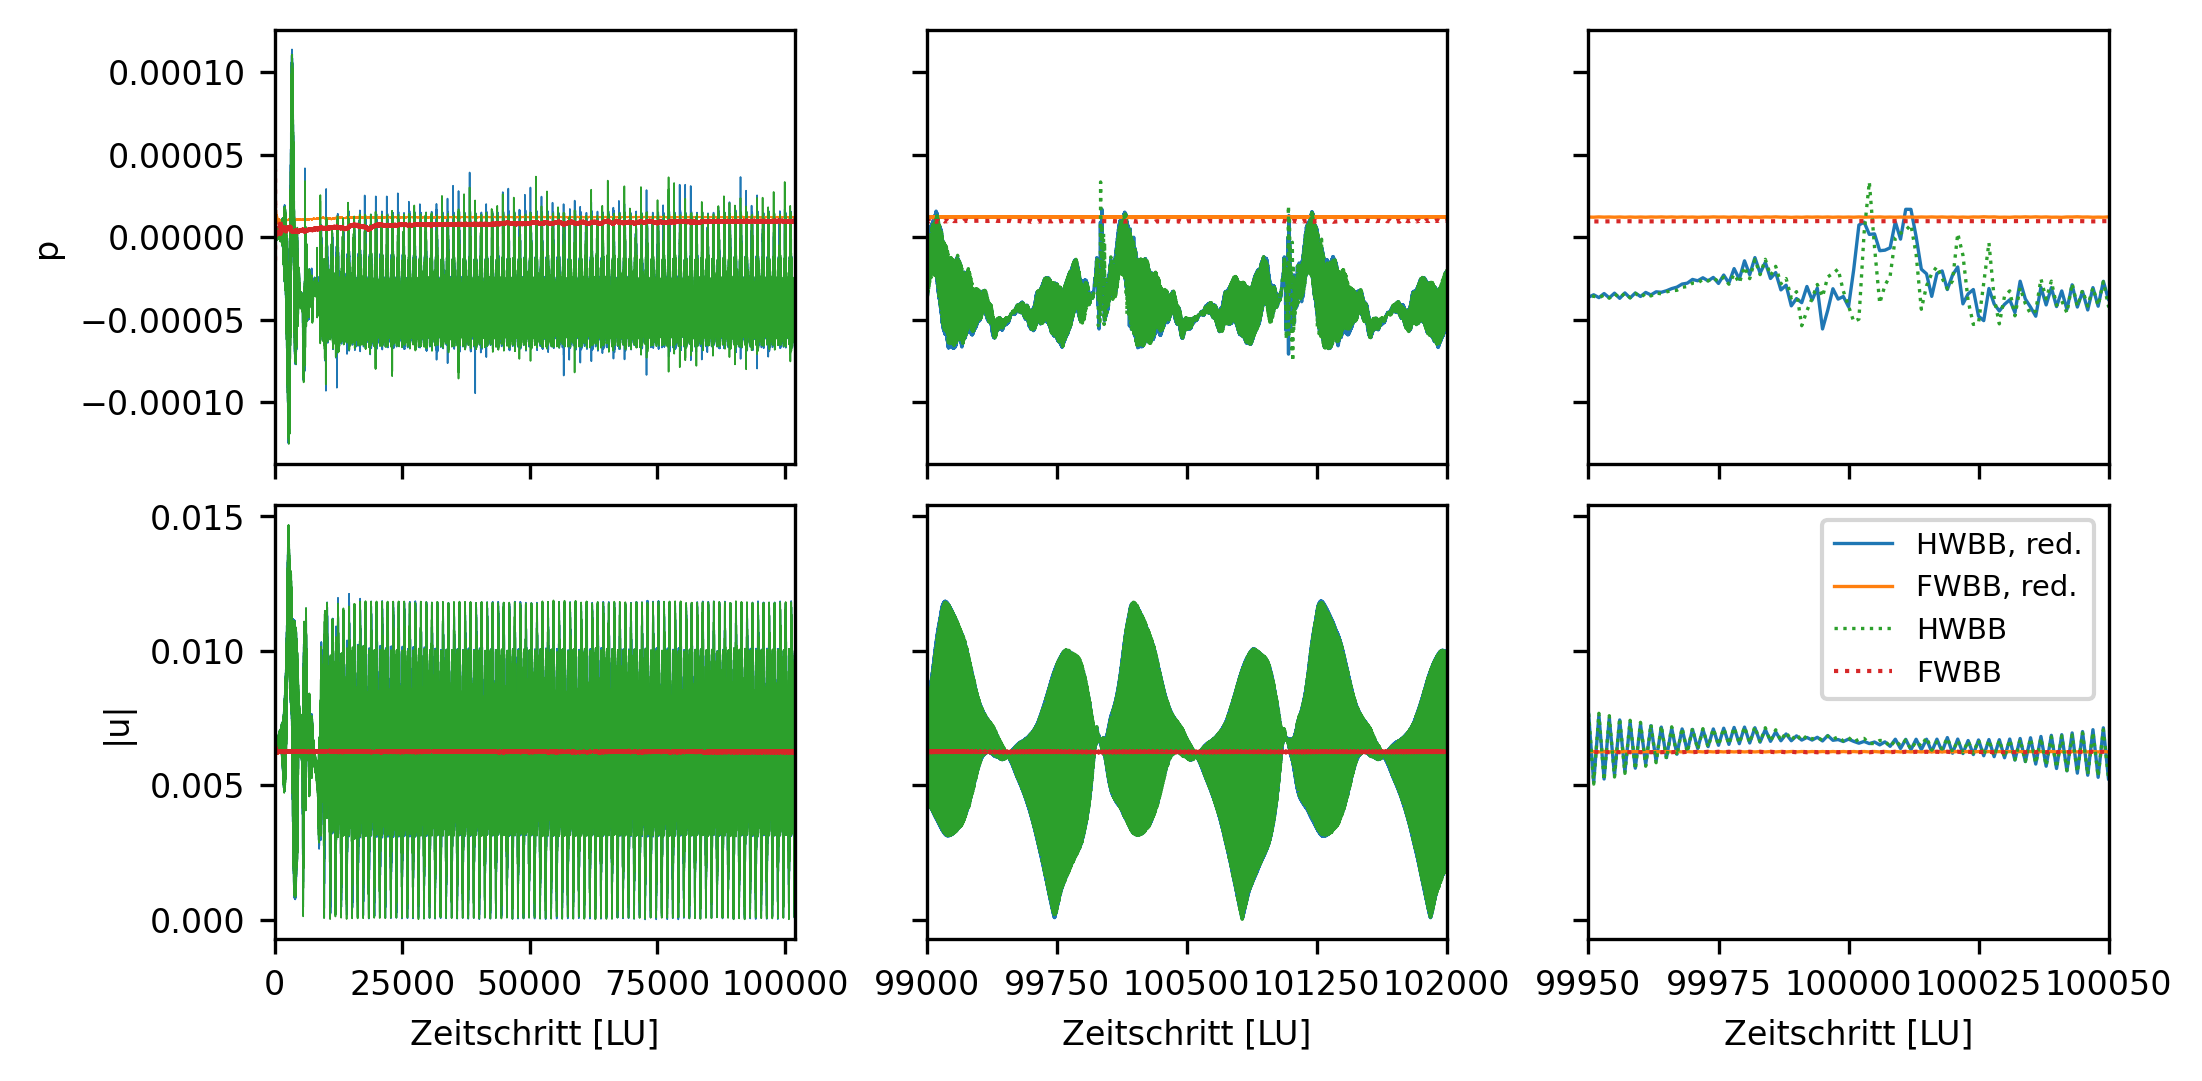

In [37]:
matplotlib.rcParams.update({'lines.linewidth': 1})
matplotlib.rcParams.update({'font.size': 8})


ma = 0.05
re = 10000
gbc = ""
x_position = 3
y_position = 3

data_ref_hwbb = pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position]
data_reduced_hwbb = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
data_ref_fwbb = pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position]
data_reduced_fwbb = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]


plot_title = False

plotting_batch_label = "plate_"  # put as prefix to name before saving...

# xlims = [[99900,100200], [99000,102000]]  # see below

# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5

xticks_list = np.linspace(0, 100000, 5)

fig_1, axs_1 = plt.subplots(2,3,sharex='col',sharey='row', 
                            figsize=(7.22433,  3.4876))

axs_1[0,0].plot(pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB, red.")
axs_1[0,0].plot(pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="FWBB, red.")
axs_1[0,0].plot(pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB")
axs_1[0,0].plot(pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=1, ls='dotted', label="FWBB")

#axs_1[0,0].set_xlabel("Zeitschritt [LU]")
#OLD: ax.set_ylim([0.7,1.7])  #TODO: mal "get" das Limit und dann mit 1e-4 vergleichen und das niedrigere nehmen.
#axs_1[0,0].set_xlim(left=100)
#axs_1[0,0].set_xlim([99900,100200])  # full, 99900-100200, 99000-102000
axs_1[0,0].set_xlim([0,102000])
axs_1[1,0].set_xticks(xticks_list)
axs_1[0,0].set_ylabel("p")
#axs_1[0,0].legend(fontsize=5)
if plot_title:
    plt.suptitle("p(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + " _at " + "LU("+str(x_position)+" ," + str(y_position)+")")
# plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "p(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
# plt.show()
#plt.close(p_fig)


# u_mag
# reduced HWBB vs. FWBB
axs_1[1,0].plot(data_reduced_hwbb[:,0], np.sqrt(np.square(data_reduced_hwbb[:, 3]) + np.square(data_reduced_hwbb[:, 4]) + np.square(data_reduced_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB, red.")
axs_1[1,0].plot(data_reduced_fwbb[:,0], np.sqrt(np.square(data_reduced_fwbb[:, 3]) + np.square(data_reduced_fwbb[:, 4]) + np.square(data_reduced_fwbb[:, 5])), marker="", linewidth=0.8, label="FWBB, red.")
# full HWBB vs. FWBB
axs_1[1,0].plot(data_ref_hwbb[:,0], np.sqrt(np.square(data_ref_hwbb[:, 3]) + np.square(data_ref_hwbb[:, 4]) + np.square(data_ref_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB")
axs_1[1,0].plot(data_ref_fwbb[:,0], np.sqrt(np.square(data_ref_fwbb[:, 3]) + np.square(data_ref_fwbb[:, 4]) + np.square(data_ref_fwbb[:, 5])), marker="", linewidth=1, ls='dotted', label="FWBB")


axs_1[1,0].set_xlabel("Zeitschritt [LU]")
#axs_1[1,0].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#axs_1[1,0].set_xlim(left=100)
#axs_1[1,0].set_xlim([9000,11000])
#axs_1[1,0].set_xlim([99900,100200])
axs_1[1,0].set_xlim([0,102000])
axs_1[1,0].set_xticks(xticks_list)
axs_1[1,0].set_ylabel("|u|")
#axs_1[1,0].legend(fontsize=5)
if plot_title:
    plt.suptitle("u_mag(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
# plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_mag(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
# plt.show()

xlims = [[99000,102000], [99950,100050]]  #[[99000,102000], [99900,100100]]

# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5

for xlim_index in range(len(xlims)):

    xticks_list = np.linspace(xlims[xlim_index][0], xlims[xlim_index][1], 5)
    
    # p
    axs_1[0,xlim_index+1].plot(pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.8, label="HWBB, red.")
    axs_1[0,xlim_index+1].plot(pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.8, label="FWBB, red.")
    axs_1[0,xlim_index+1].plot(pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.8, ls='dotted',label="HWBB")
    axs_1[0,xlim_index+1].plot(pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=1, ls='dotted', label="FWBB")

    #axs_1[0,xlim_index+1].set_xlabel("Zeitschritt [LU]")
    #OLD: ax.set_ylim([0.7,1.7])  #TODO: mal "get" das Limit und dann mit 1e-4 vergleichen und das niedrigere nehmen.
    #axs_1[0,0].set_xlim(left=100)
    axs_1[0,xlim_index+1].set_xlim([xlims[xlim_index][0], xlims[xlim_index][1]])  # full, 99900-100200, 99000-102000
    axs_1[0,xlim_index+1].set_xticks(xticks_list)
   # axs_1[0,xlim_index+1].set_ylabel("p")
  #  axs_1[0,xlim_index+1].legend(fontsize=5)
    if plot_title:
        plt.suptitle("p(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + " _at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    # plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "p(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlims[xlim_index][0])+"-"+str(xlims[xlim_index][1]) + ".png")
    # plt.show()
    #plt.close(p_fig)
    
    
    # u_mag
    
    # reduced HWBB vs. FWBB
    axs_1[1,xlim_index+1].plot(data_reduced_hwbb[:,0], np.sqrt(np.square(data_reduced_hwbb[:, 3]) + np.square(data_reduced_hwbb[:, 4]) + np.square(data_reduced_hwbb[:, 5])), marker="", linewidth=0.8, label="HWBB, red.")
    axs_1[1,xlim_index+1].plot(data_reduced_fwbb[:,0], np.sqrt(np.square(data_reduced_fwbb[:, 3]) + np.square(data_reduced_fwbb[:, 4]) + np.square(data_reduced_fwbb[:, 5])), marker="", linewidth=0.8, label="FWBB, red.")
    # full HWBB vs. FWBB
    axs_1[1,xlim_index+1].plot(data_ref_hwbb[:,0], np.sqrt(np.square(data_ref_hwbb[:, 3]) + np.square(data_ref_hwbb[:, 4]) + np.square(data_ref_hwbb[:, 5])), marker="", linewidth=0.8, ls='dotted', label="HWBB")
    axs_1[1,xlim_index+1].plot(data_ref_fwbb[:,0], np.sqrt(np.square(data_ref_fwbb[:, 3]) + np.square(data_ref_fwbb[:, 4]) + np.square(data_ref_fwbb[:, 5])), marker="", linewidth=1, ls='dotted', label="FWBB")
    
    axs_1[1,xlim_index+1].set_xlabel("Zeitschritt [LU]")
    #axs_1[1,xlim_index+1].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #axs_1[1,xlim_index+1].set_xlim(left=100)
    #axs_1[1,xlim_index+1].set_xlim([9000,11000])
    
    axs_1[1,xlim_index+1].set_xlim(xlims[xlim_index])
    axs_1[1,xlim_index+1].set_xticks(xticks_list)
    #axs_1[1,xlim_index+1].set_ylabel("|u|")
   # axs_1[1,xlim_index+1].legend(fontsize=5)
    if plot_title:
        plt.suptitle("u_mag(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    # plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_mag(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlims[xlim_index][0])+"-"+str(xlims[xlim_index][1]) + ".png")
    # plt.show()

axs_1[1,2].legend(fontsize=7)
axs_1[1,2].ticklabel_format(useOffset=False)#style='plain')
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_mag_p_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+").png")
plt.show()

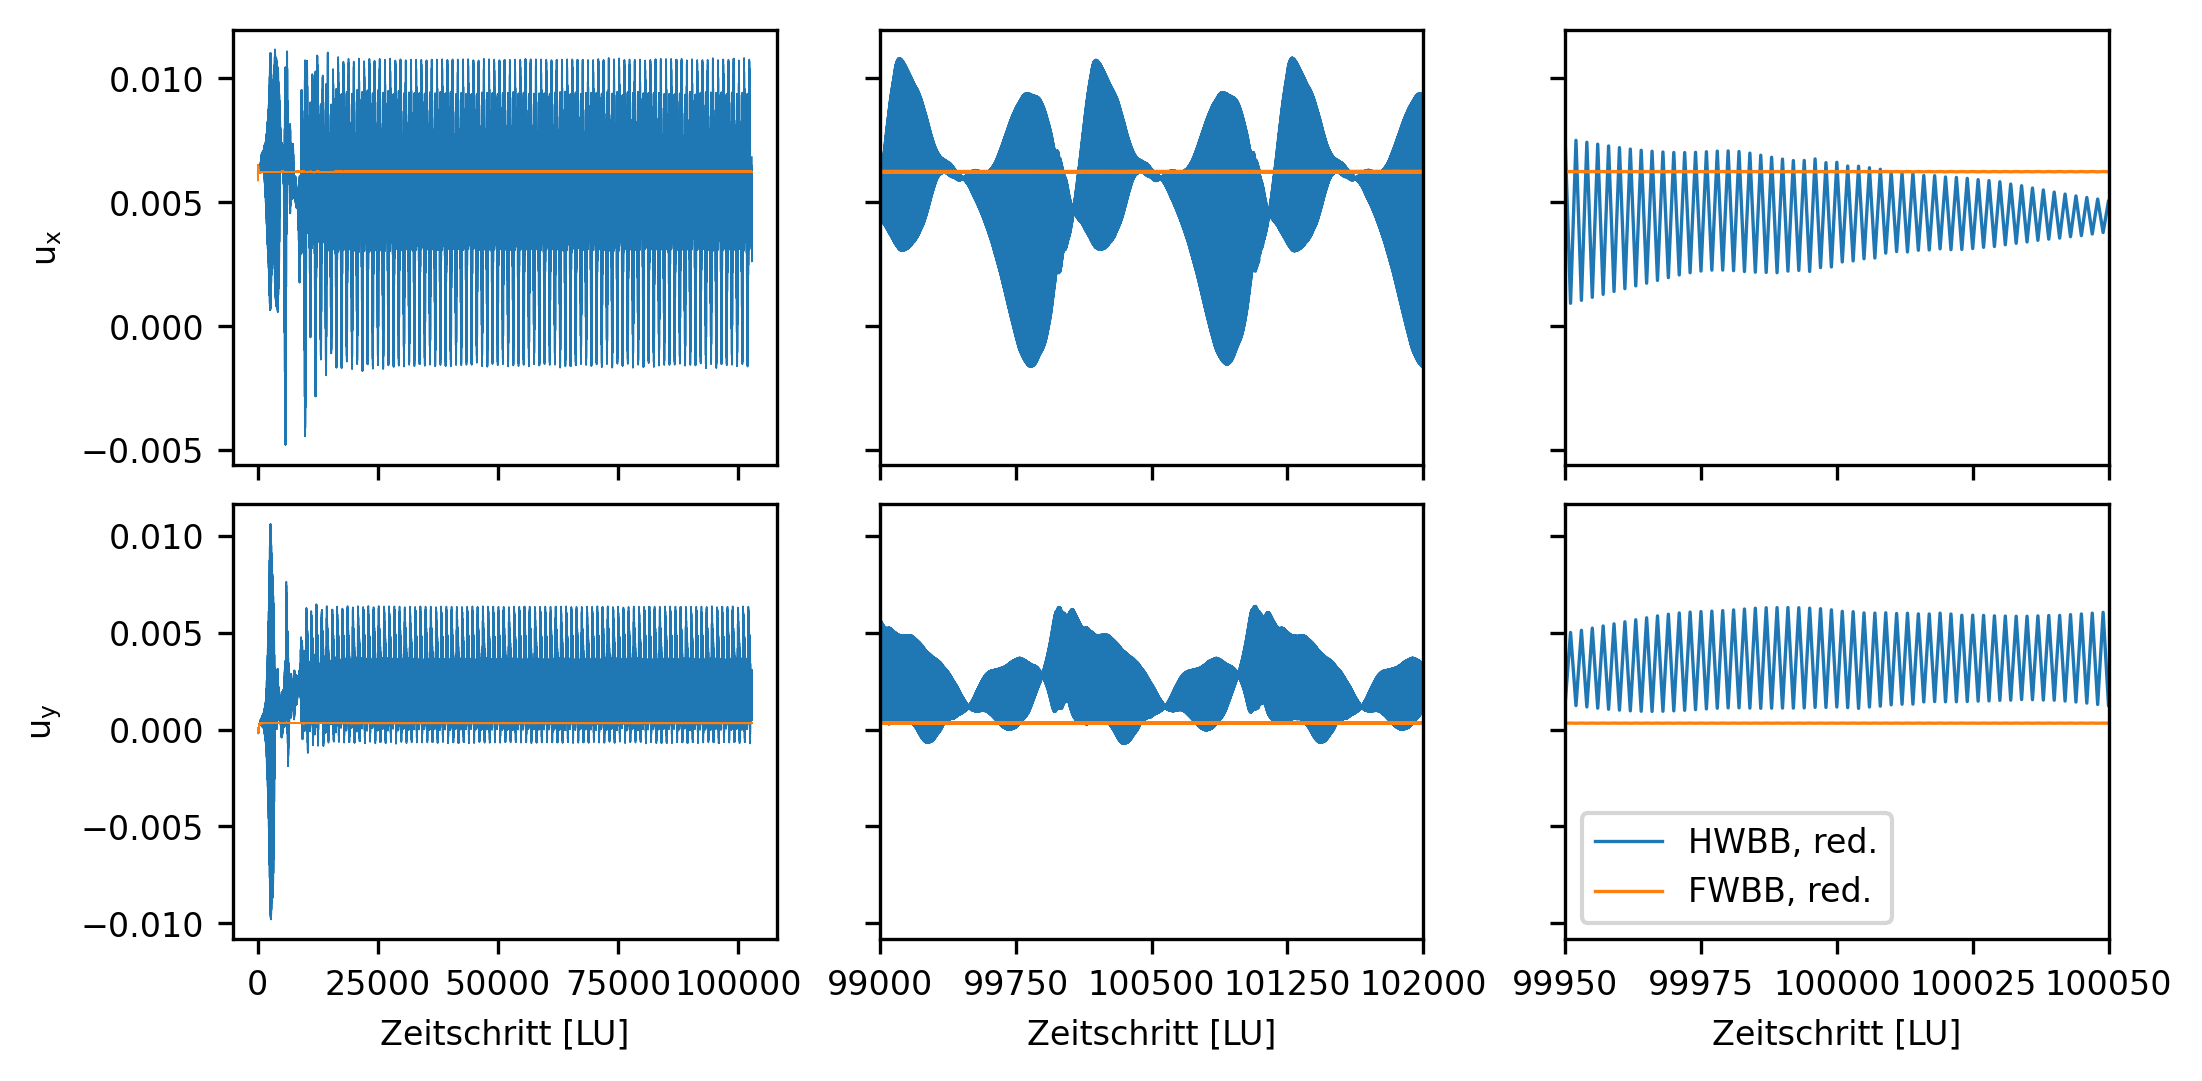

In [40]:
# plot again for zoomed section of x-axis... (time) to see oscillation

fig_2, axs_2 = plt.subplots(2,3,sharex='col',sharey='row', 
                            figsize=(7.22433,  3.4876))

# ux

data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
axs_2[0,0].plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="HWBB, red.")

data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
axs_2[0,0].plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="FWBB, red.")



#axs_2[0,-].set_xlabel("Zeitschritt [LU]")
#axs_2[0,-].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#axs_2[0,-].set_xlim(left=100)
#axs_2[0,-].set_xlim([9000,11000])
#axs_2[0,-].set_xlim([99900,100200])
axs_1[0,0].set_xlim([0,102000])
axs_2[0,0].set_ylabel(r"$\mathrm{u_x}$")
#axs_2[0,0].legend(fontsize=5)
if plot_title:
    plt.suptitle("ux(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")


# uy
data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
axs_2[1,0].plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="HWBB, red.")

data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
axs_2[1,0].plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="FWBB, red.")



axs_2[1,0].set_xlabel("Zeitschritt [LU]")
#axs_2[0,-].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#axs_2[0,-].set_xlim(left=100)
#axs_2[0,-].set_xlim([9000,11000])
#axs_2[0,-].set_xlim([99900,100200])
axs_1[1,0].set_xlim([0,102000])
axs_2[1,0].set_ylabel(r"$\mathrm{u_y}$")
#axs_2[1,0].legend(fontsize=5)
if plot_title:
    plt.suptitle("uy(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")

# # uz
# 
# data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
# axs_2[0,-].plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="HWBB, red.")
# 
# data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
# axs_2[0,-].plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="FWBB, red.")
# 
# 
# 
# axs_2[0,-].set_xlabel("Zeitschritt [LU]")
# axs_2[0,-].set_ylim([-0.0001,0.0001])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
# #axs_2[0,-].set_xlim(left=100)
# #axs_2[0,-].set_xlim([9000,11000])
# #axs_2[0,-].set_xlim([99900,100200])
# axs_2[0,-].set_ylabel(r"$\mathrm{u_z}$")
# axs_2[0,-].legend(fontsize=5)
# if plot_title:
#     plt.suptitle("uz(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
# plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "uz(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
# plt.show()


xlims = [[99000,102000], [99950,100050]] # [[99000,102000], [99900,100100]]

# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5

for xlim_index in range(len(xlims)):

    xticks_list = np.linspace(xlims[xlim_index][0], xlims[xlim_index][1], 5)
    
    # ux    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    axs_2[0,xlim_index+1].plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.8, label="HWBB, red.")
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    axs_2[0,xlim_index+1].plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.8, label="FWBB, red.")
    
    
    
    #axs_2[0,xlim_index+1].set_xlabel("Zeitschritt [LU]")
    #axs_2[0,-].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #axs_2[0,-].set_xlim(left=100)
    #axs_2[0,-].set_xlim([9000,11000])
    axs_2[0,xlim_index+1].set_xlim(xlims[xlim_index])
    axs_2[0,xlim_index+1].set_xticks(xticks_list)
    #axs_2[0,xlim_index+1].set_ylabel(r"$\mathrm{u_x}$")
    #axs_2[0,xlim_index+1].legend(fontsize=5)
    if plot_title:
        plt.suptitle("ux(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    
    # uy
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    axs_2[1,xlim_index+1].plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.8, label="HWBB, red.")
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    axs_2[1,xlim_index+1].plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.8, label="FWBB, red.")
    
    
    
    axs_2[1,xlim_index+1].set_xlabel("Zeitschritt [LU]")
    #axs_2[0,-].set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #axs_2[0,-].set_xlim(left=100)
    #axs_2[0,-].set_xlim([9000,11000])
    axs_2[1,xlim_index+1].set_xlim(xlims[xlim_index])
    axs_2[1,xlim_index+1].set_xticks(xticks_list)
    #axs_2[1,xlim_index+1].set_ylabel(r"$\mathrm{u_y}$")
    #axs_2[1,xlim_index+1].legend(fontsize=5)
    if plot_title:
        plt.suptitle("uy(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    
    # # uz
    # 
    # data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    # axs_2[0,-].plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="HWBB, red.")
    # 
    # data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # # axs_2[0,-].plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    # axs_2[0,-].plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="FWBB, red.")
    # 
    # 
    # 
    # axs_2[0,-].set_xlabel("Zeitschritt [LU]")
    # axs_2[0,-].set_ylim([-0.0001,0.0001])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    # #axs_2[0,-].set_xlim(left=100)
    # #axs_2[0,-].set_xlim([9000,11000])
    # axs_2[0,-].set_xlim(xlim)
    # axs_2[0,-].set_xticks(xticks_list)
    # axs_2[0,-].set_ylabel(r"$\mathrm{u_z}$")
    # axs_2[0,-].legend(fontsize=5)
    # if plot_title:
    #     plt.suptitle("uz(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")

axs_2[1,2].ticklabel_format(useOffset=False)#style='plain')
axs_2[1,2].legend(fontsize=8)
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_comp_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+").png")
plt.show()



In [11]:
#todo: Plots in zweimal 3x2 basteln mit individuellen Achsen
# - ALTERNATIV: eine Version mit 2x3 Plot mit vereinten Achsen